# MULTIPLE LINEAR REGRESSION :

#### Assignment Task:

Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.

#### Dataset Description:

The dataset consists of the following variables:
Age: Age in years
KM: Accumulated Kilometers on odometer
FuelType: Fuel Type (Petrol, Diesel, CNG)
HP: Horse Power
Automatic: Automatic ( (Yes=1, No=0)
CC: Cylinder Volume in cubic centimeters
Doors: Number of doors
Weight: Weight in Kilograms
Quarterly_Tax:
Price: Offer Price in EUROs

### Tasks:

#### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
# Load the data set
df=pd.read_csv("ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [58]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [59]:
# shape of the data set
df.shape

(1436, 11)

In [60]:
# Size of the data set
df.size

15796

In [61]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [62]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [63]:
# checking missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [64]:
# checking duplicated value
df.duplicated().sum()

np.int64(1)

In [65]:
# drop duplicates values
df.drop_duplicates(inplace = True)

In [66]:
# Again checking
df.duplicated().sum()

np.int64(0)

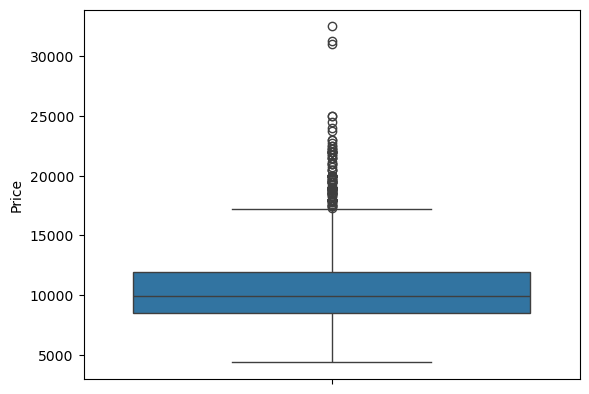

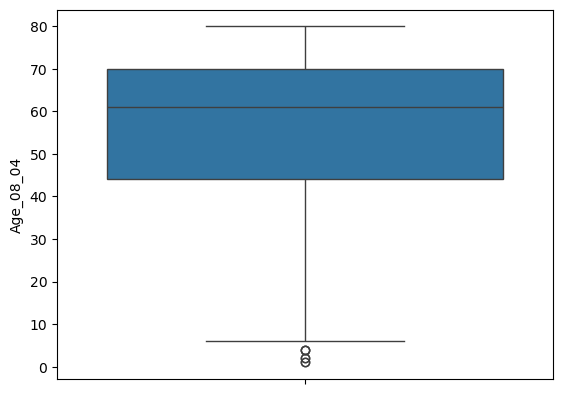

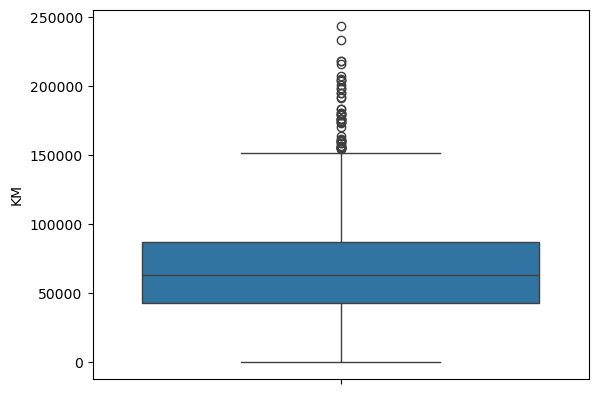

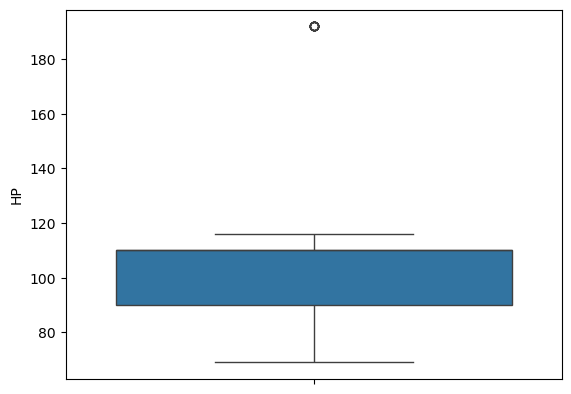

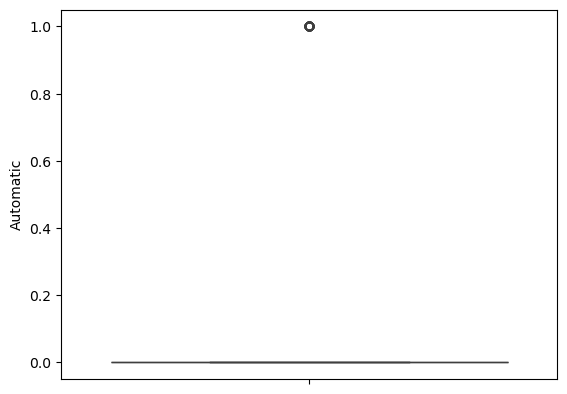

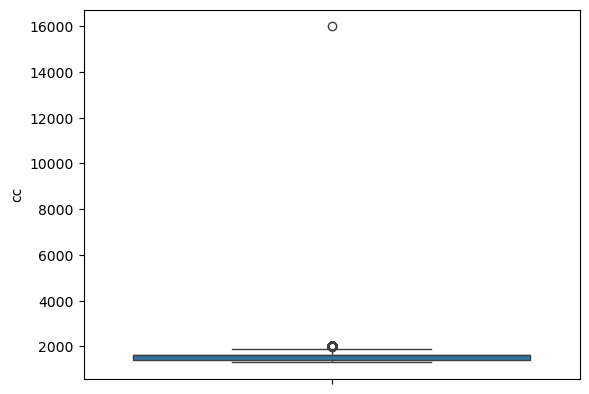

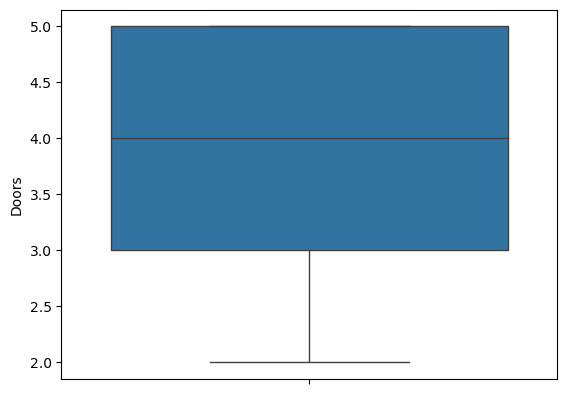

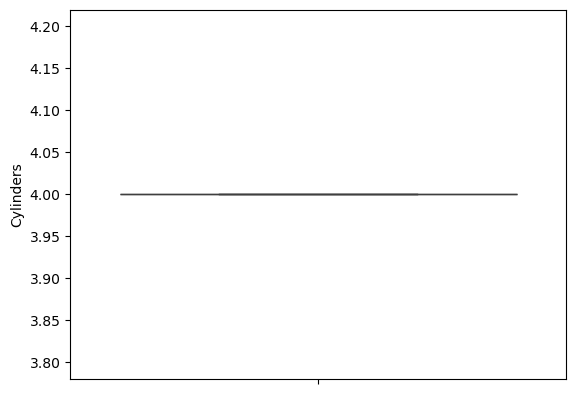

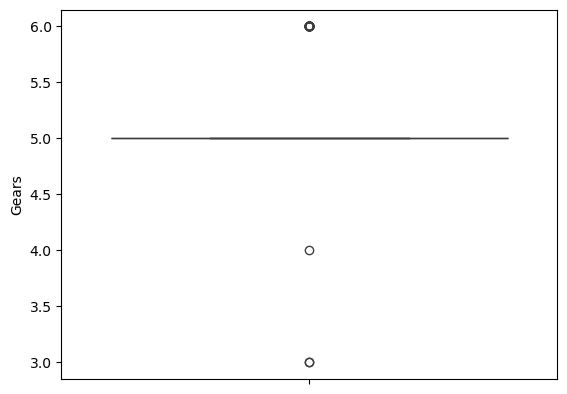

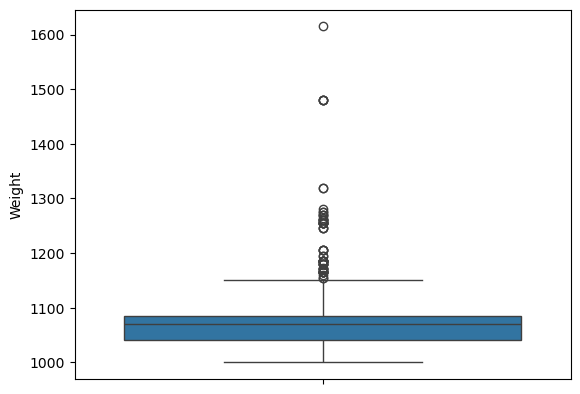

In [67]:
# Checking outlier
import matplotlib.pyplot as plt
import seaborn as sns
for col in df.select_dtypes(include = ['int','float']).columns:
    sns.boxplot(df[col])
    plt.show()


In [68]:
# Ouitlier Capping 
for col in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1 

    lower_bound = q1 - 1.5* IQR
    upper_bound = q3 + 1.5* IQR

    df[col] = df[col].clip(lower_bound, upper_bound)

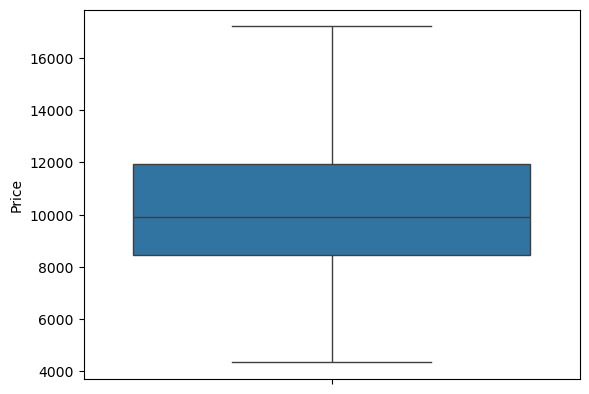

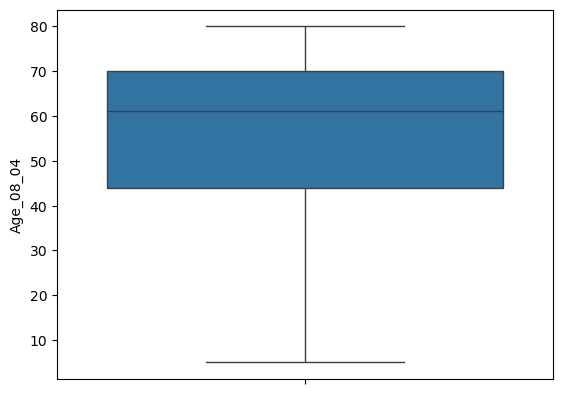

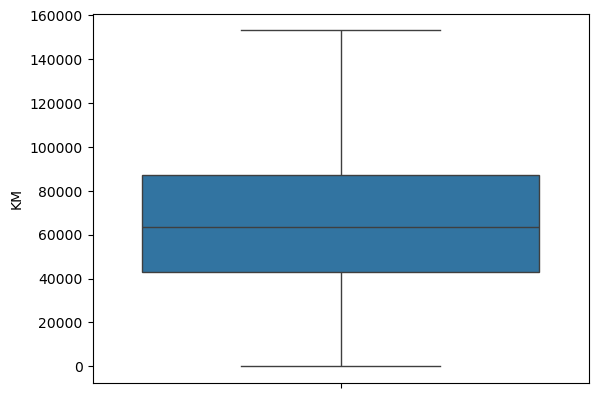

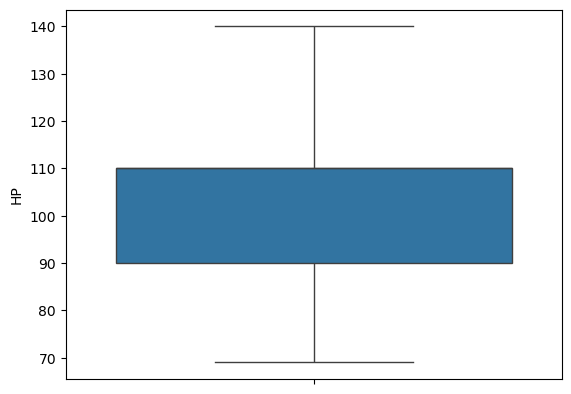

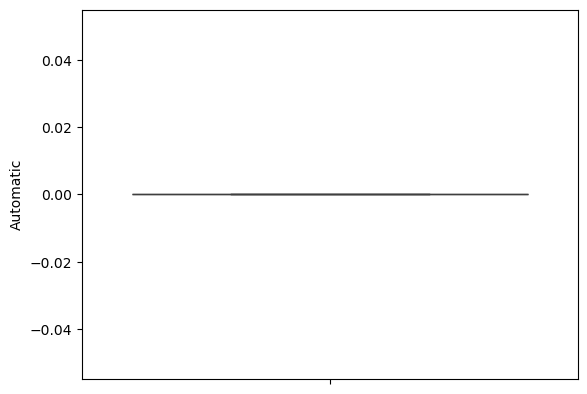

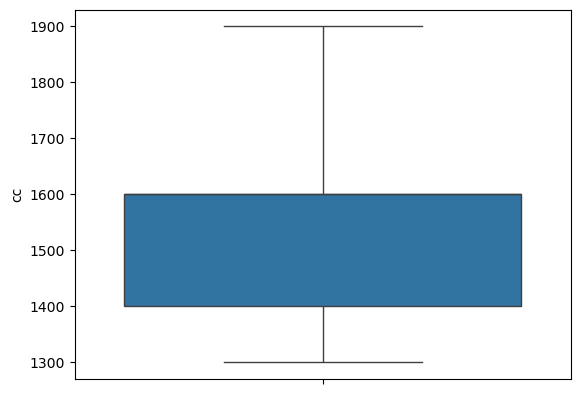

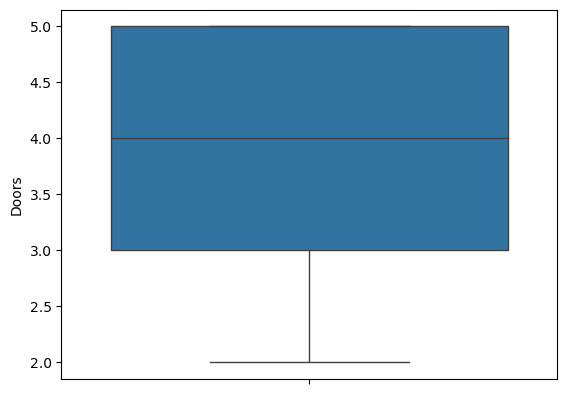

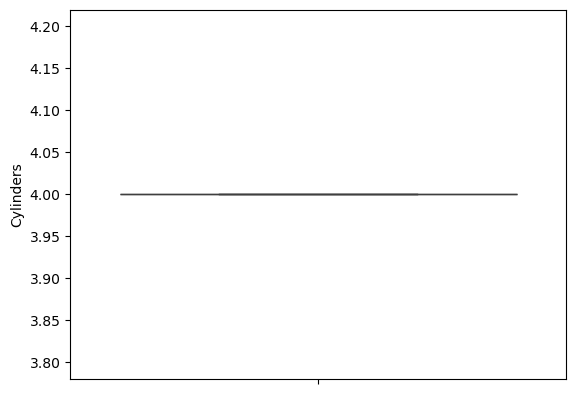

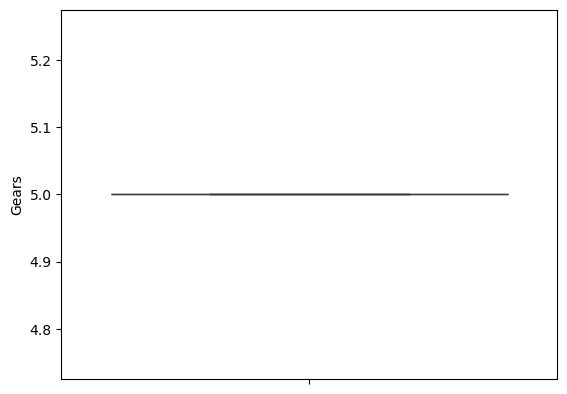

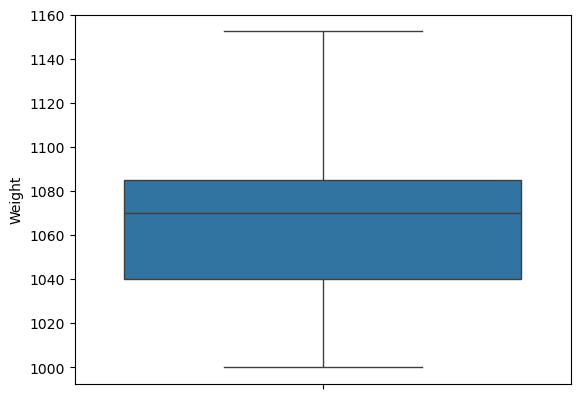

In [69]:
# Verify 
for col in df.select_dtypes(include = ['int','float']).columns:   
    sns.boxplot(df[col])
    plt.show()

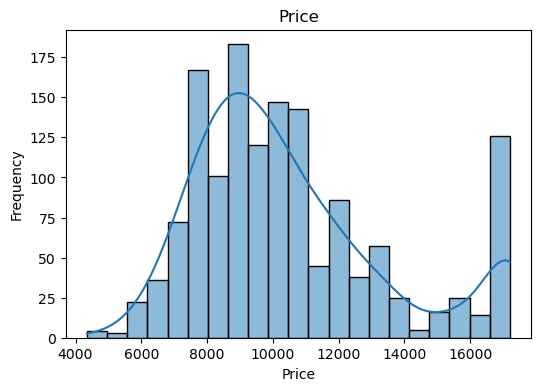

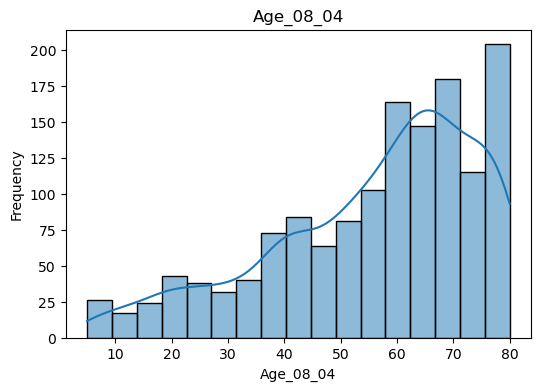

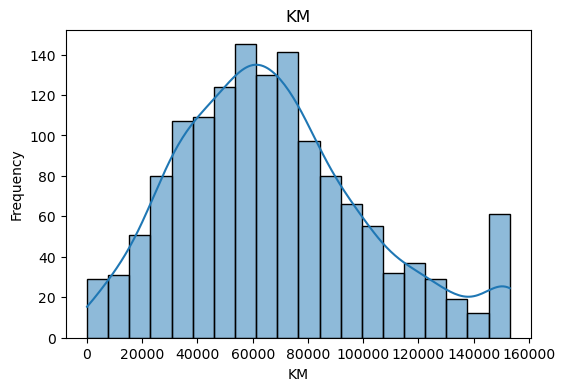

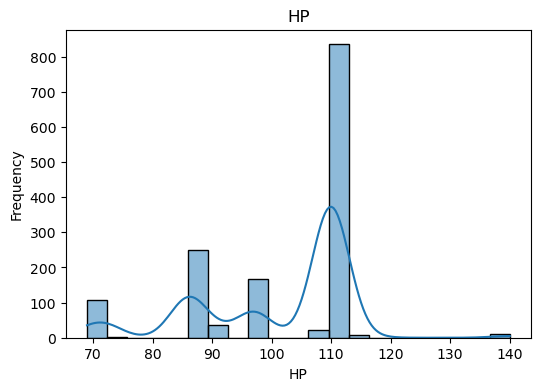

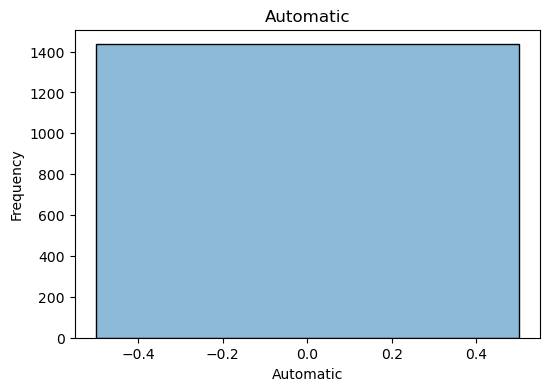

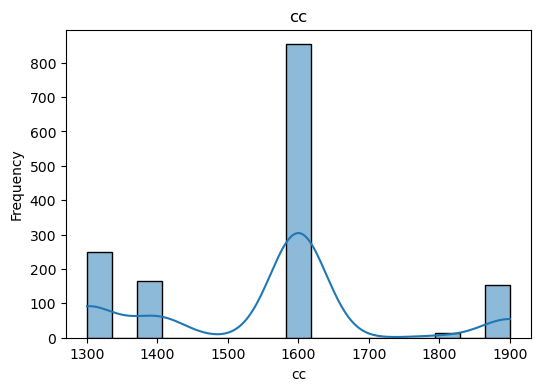

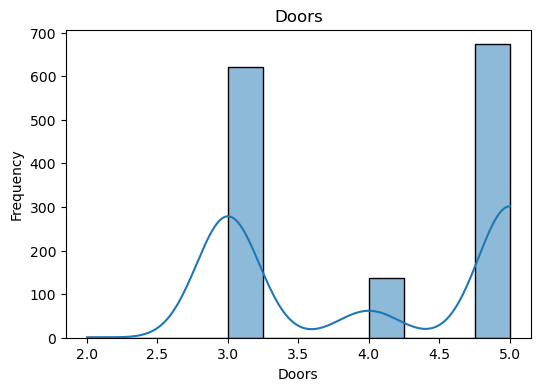

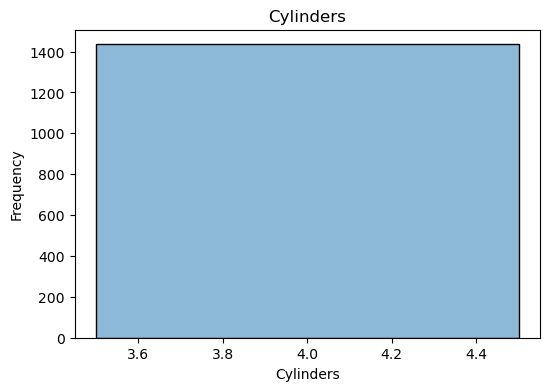

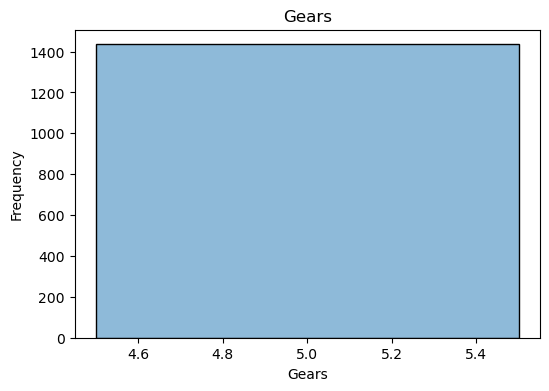

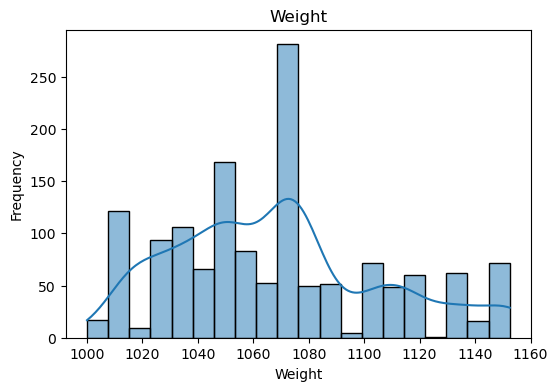

In [70]:
# Visualization for numerical columns
# Histplot 
for col in df.select_dtypes(include = ['int','float']).columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True)
    plt.title (col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

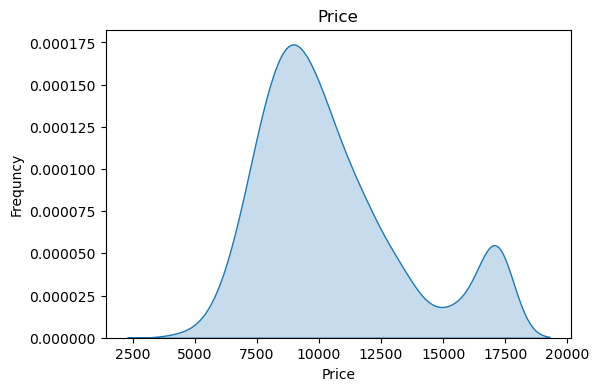

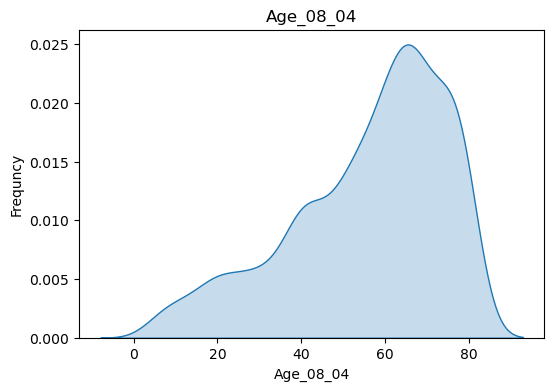

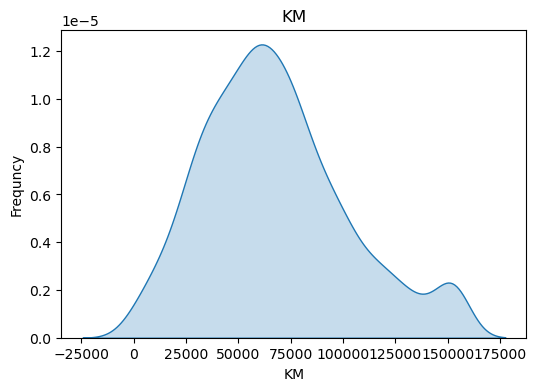

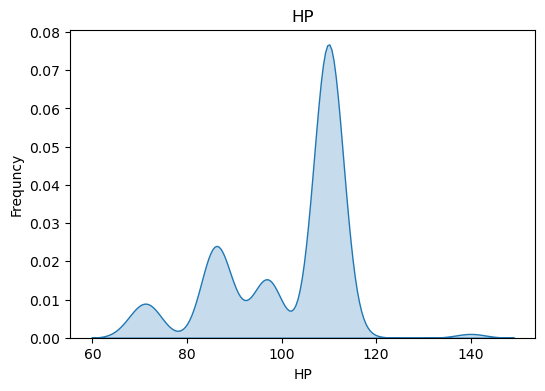

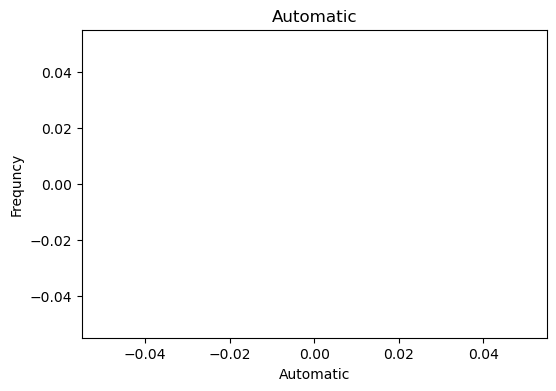

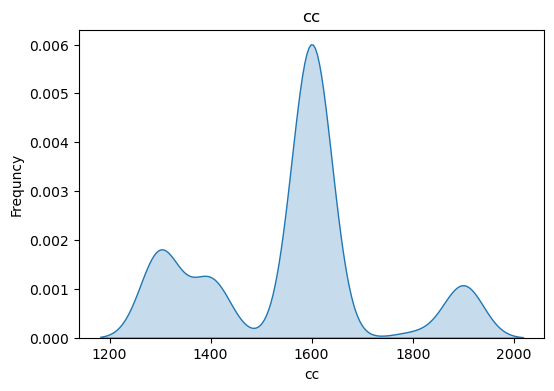

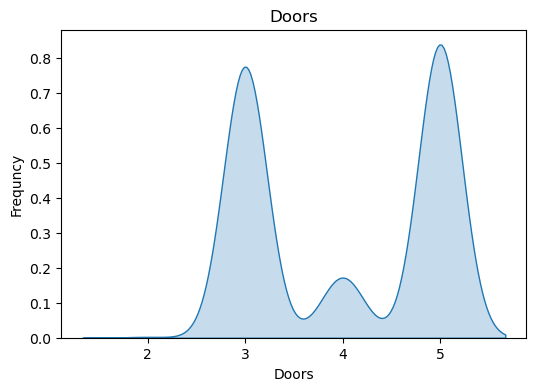

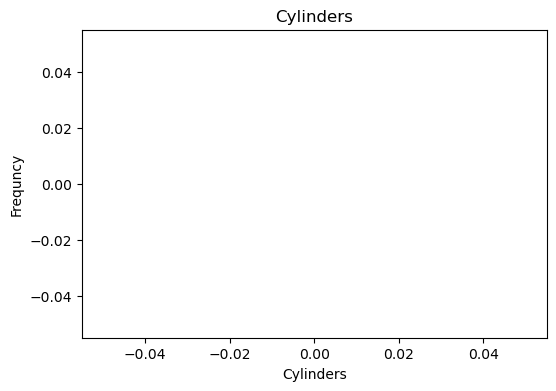

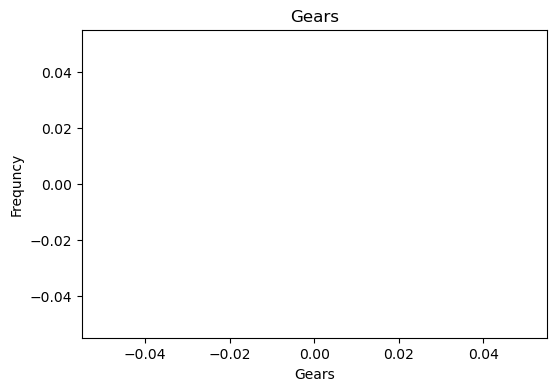

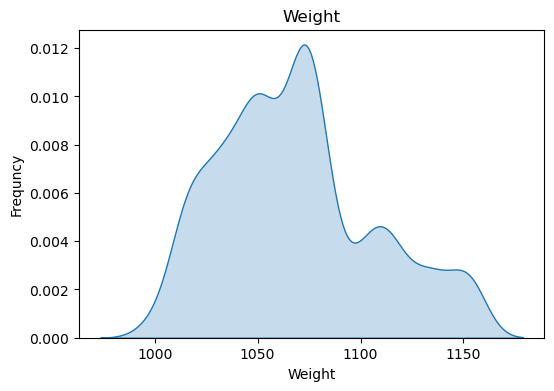

In [71]:
# KDE plot 
for col in df.select_dtypes(include = ['int','float']).columns:
    plt.figure(figsize = (6,4))
    sns.kdeplot(df[col], fill = True)
    plt.title (col)
    plt.xlabel(col)
    plt.ylabel("Frequncy")
    plt.show()

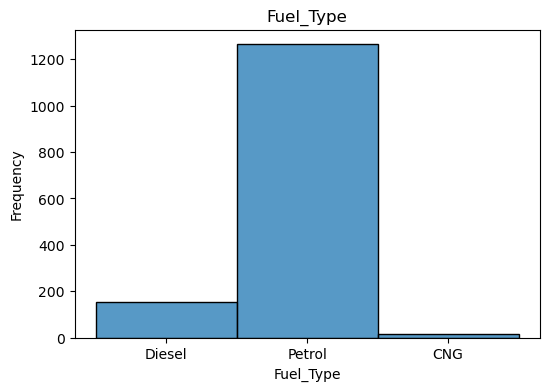

In [72]:
# Histplot for Categorical Data

cat_cols = df.select_dtypes(include = 'object').columns
plt.figure(figsize = (6,4))
sns.histplot (df['Fuel_Type'])
plt.title("Fuel_Type")
plt.xlabel("Fuel_Type")
plt.ylabel("Frequency")
plt.show()

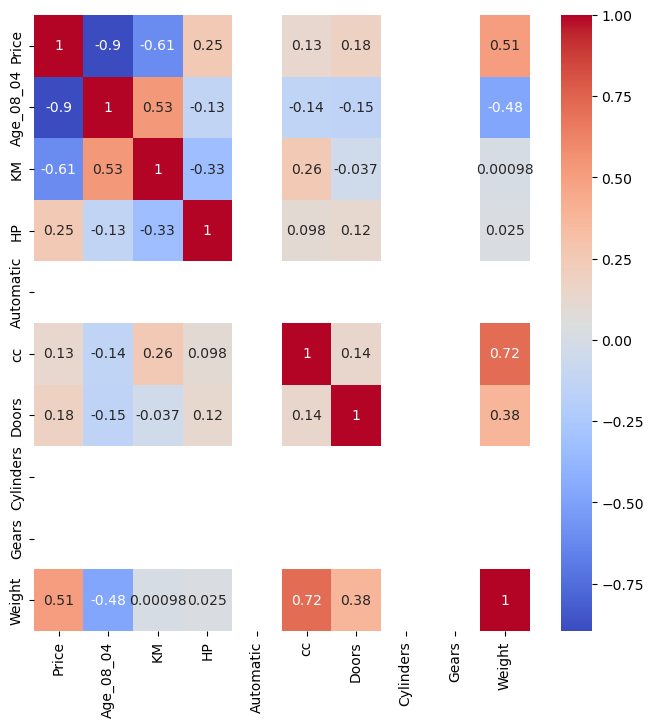

In [73]:
# Correlation Matrix

num_cols = df.select_dtypes(include = ['int','float']).columns
corr = df[num_cols].corr()
plt.figure(figsize = (8,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

In [74]:
# Drop Unwanted Columns 
df.drop(columns = ['Automatic','Cylinders','Gears'], inplace = True)

In [75]:
# Label Encoding for Categorical Columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

In [76]:
# Extract the feature and Target 
x = df.drop(columns = 'Price')
y = df['Price']

In [77]:
# Split the Dataset 
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x , y , test_size = 0.2, random_state = 42)

In [78]:
print("The Shape of x_train:", x_train.shape)
print("The Shape of x_test:" , x_test.shape)
print("The Shape of y_train:", y_train.shape)
print("The shape of y_test:", y_test.shape)

The Shape of x_train: (1148, 7)
The Shape of x_test: (287, 7)
The Shape of y_train: (1148,)
The shape of y_test: (287,)


### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [79]:
# Scaling 
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [80]:
# Model Building (Linear Regression)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

In [81]:
# Tree Based Model (Decision Tree Regressor)
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(max_leaf_nodes = 20,
                            max_depth  = 20,
                            min_samples_split = 80,
                            random_state = 42
                           )
dtr.fit(x_train, y_train)
dtr_pred = dtr.predict(x_test)

In [82]:
# Ensemble Method (Random Forest Regressor)
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(x_train, y_train)
rfr_pred = rfr.predict(x_test)

 
#### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [83]:
# Evaluate the Performance of Linear Regression 
from sklearn.metrics import (
                mean_absolute_error,
                mean_squared_error,
                root_mean_squared_error,
                r2_score                
)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_r2score = r2_score(y_test, lr_pred)

print("="*60)
print("Linear Regression")
print("="*60)

print("MAE: ",lr_mae)
print("MSE: ",lr_mse)
print("RMSE: ",lr_rmse)
print("R2_score: ",lr_r2score)

Linear Regression
MAE:  874.9051254504081
MSE:  1278904.3704666793
RMSE:  1130.8865418187092
R2_score:  0.8500391836545926


In [84]:

# Evaluate the performance of DecisionTree Regression 
from sklearn.metrics import (
                mean_absolute_error,
                mean_squared_error,
                root_mean_squared_error,
                r2_score                
)

dtr_mae = mean_absolute_error(y_test, dtr_pred)
dtr_mse = mean_squared_error(y_test, dtr_pred)
dtr_rmse = root_mean_squared_error(y_test, dtr_pred)
dtr_r2score = r2_score(y_test, dtr_pred)

print("="*60)
print("DecisionTree Regression")
print("="*60)

print("MAE: ",dtr_mae)
print("MSE: ",dtr_mse)
print("RMSE: ",dtr_rmse)
print("R2_score: ",dtr_r2score)

DecisionTree Regression
MAE:  796.7511276529898
MSE:  1064024.5120420984
RMSE:  1031.5156382925556
R2_score:  0.875235406085029


In [85]:
# Evaluate the performance of Random Forest Regressor  
from sklearn.metrics import (
                mean_absolute_error,
                mean_squared_error,
                root_mean_squared_error,
                r2_score                
)

rfr_mae = mean_absolute_error(y_test, rfr_pred)
rfr_mse = mean_squared_error(y_test, rfr_pred)
rfr_rmse = root_mean_squared_error(y_test, rfr_pred)
rfr_r2score = r2_score(y_test, rfr_pred)

print("="*60)
print("Random Forest Regressor")
print("="*60)

print("MAE: ",rfr_mae)
print("MSE: ",rfr_mse)
print("RMSE: ",rfr_rmse)
print("R2_score: ",rfr_r2score)

Random Forest Regressor
MAE:  762.0392334494775
MSE:  1049839.8527482774
RMSE:  1024.6169297587646
R2_score:  0.8768986603020013


#### 5.Apply Lasso and Ridge methods on the model.

In [86]:
# APPLY LASSO 
# Import Libraries 
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error,mean_absolute_error


lasso = Lasso(
    alpha = 0.1, 
    max_iter = 20,
    random_state = 42
)

# Fit the Model
lasso.fit(x_train,y_train)

# Prediction 
lasso_pred = lasso.predict(x_test)

# Accuracy 
print("=" * 60)
print("Lasso Accuracy ")
print("="*60)

print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("MSE:", mean_squared_error(y_test, lasso_pred))
print("RMSE:", root_mean_squared_error(y_test, lasso_pred))
print("R2_Score:", r2_score(y_test, lasso_pred))

Lasso Accuracy 
MAE: 874.7058669113615
MSE: 1278438.5236871175
RMSE: 1130.6805577558666
R2_Score: 0.850093807569381


In [87]:
## APPLY RIDGE 
# Import Libraries 
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error,mean_absolute_error

ridge =  Ridge(
    alpha = 0.1,
    max_iter = 20,
    random_state = 42
)

# Fit the Model 
ridge.fit(x_train, y_train)

# Prediction 
ridge_pred = ridge.predict(x_test)

print("=" * 60)
print("Ridge Accuracy")
print("=" * 60)

# Accuracy 
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("RMSE:", root_mean_squared_error(y_test, ridge_pred))
print("R2_Score:", r2_score(y_test, ridge_pred))

Ridge Accuracy
MAE: 874.9000471905375
MSE: 1278900.135848119
RMSE: 1130.8846695610118
R2_Score: 0.8500396801943424


# Interview Questions:

### 1.What is Normalization & Standardization and how is it helpful?
Normalization

is a feature scaling technique that transforms numerical data into a fixed range, typically 0 to 1, using the Min-Max Scaling formula. It helps ensure that all features contribute equally during model training, prevents features with larger values from dominating, and improves the performance of distance-based algorithms such as KNN, K-Means, and Neural Networks. However, normalization is generally not required for tree-based models like Decision Trees and Random Forests.
Normalization is helpful because:
It brings all features to the same scale.
It prevents features with larger values from dominating features with smaller values.
It improves the performance and convergence speed of many machine learning algorithms.
It makes distance calculations more meaningful in distance-based algorithms.
Standardization is a feature scaling technique that transforms data so that each feature has a mean of 0 and a standard deviation of 1 using the Z-score formula. It helps machine learning algorithms by bringing all features to a common scale, improving convergence, reducing the effect of different feature magnitudes, and enhancing the performance of models such as Linear Regression, Logistic Regression, SVM, PCA, and Neural Networks. Tree-based algorithms like Decision Trees and Random Forests generally do not require standardization.
Standardization is helpful because:
It makes all features have the same scale.
It improves the performance of algorithms that use gradients or distances.
It speeds up model training and convergence.
It prevents features with large numerical values from dominating smaller-valued features.

### 2.What techniques can be used to address multicollinearity in multiple linear regression?
Techniques to Address Multicollinearity :

### 1. Remove Highly Correlated Features (Most Common)

If two features are highly correlated, remove one of them.

### 2. Ridge Regression (L2 Regularization)

Ridge Regression adds a penalty to the regression coefficients, reducing the impact of multicollinearity without removing features.
It shrinks the coefficients of correlated variables toward zero but usually does not make them exactly zero.
Best when:
You want to keep all features.
Features are highly correlated.

### 3. Lasso Regression (L1 Regularization)

Lasso Regression also adds a penalty but can shrink some coefficients exactly to zero, effectively removing less important features. Best when:
Feature selection is needed.
There are many correlated features.

### 4. Elastic Net Regression

Elastic Net combines both Ridge (L2) and Lasso (L1) penalties.
Advantages:
Handles multicollinearity.
Performs feature selection.
Works well when many predictors are correlated.